# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv') 

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print((users.isna().mean() * 100).round(2))

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico de valores nulos**
En el dataset "users", la columna "city"presenta un 11.72% de valores faltantes, por lo tanto sera necesario investigar su origen y tamnbien evaluar la mejor estrategia de tratamiento. La columna "churn_date" contiene un 88.35% de valores nulos; sin embargo debemos tomar en cuenta que estos podian representar cliente que aun permanecen activos, por lo que no se eliminaran hasta confirmar su significado. 

En el dataset "usage", la columna "date" presenta únicamente un 0.12% de valores faltantanes, por lo que se revisarán esos registros durante la limpieza. Las columnas "duration" tienen un 55.19% de nulos y length un 44.74%, que podríamos considerar como una proporción alta de nulos, pero se sospecha que corresponden a la naturaleza del tipo de evento (call o text). Esta hipótesis será validada antes de realizer cualquier imputación o eliminación.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene identificadores unicos dentro del rango esperado. No se observan valores inválidos o insconsistentes.
- La columna `age` presenta un valor minimo de -999, el cual corresponde a un sentinel y no representa una edad válida. Este valor deberá ser reemplazado por un valor representativo, como la mediana para evitar distorsionar el análisis. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no representan anomalias.
- La columna `duration` no se observan sentinels, los valores parecen razonables.
- La columna `length` no se observan sentinels, solamente llama mi atencion el valor maximo que mas adelante voy a evaluar si es un error o un outlier. 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].value_counts(dropna=False))


Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta valores faltantes "NaN" y tambien registros con "?", que representan un sentinel. Se recomienda reemplazar el "?" por valores nulos como pd.Na para unificar el tratamiento de datos faltantes. 
- La columna `plan` no se observan inconsistencias.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se observan solo 2 categorias sin errores de escritura, eso significa que no necesita limpieza. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Diagnóstico de valores inválidos o sentinels**

Se identificó un valor inválido en la columna "age", donde aparece el sentinel `-999`, el cual no representa una edad válida y será reemplazado por la mediana de la variable. En la columna "city" se encontraron registros con el valor "?" además de valores nulos (NaN); estos registros los convertiremos a pd.NA para unificar el tratamiento de los datos faltantes. 

En las columnas "plan" y "type" no se observaron valores inesperados, ya que únicamente contienen las categorías válidas definidas para el negocio. Tambien las variables numéricas del dataset "usage" no presentan sentinels evidentes, aunque algunos valores extremos serán evaluados posteriormente durante el análisis de outliers. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se observaque contiene registros que corresponden a los años 2022, 2023 y 2024, que se encuentran dentro del periodo esperado. Sin embargo, tambien se identificaron 40 registros del año 2026 los cuales representan fechas futuras respecto al alcance del análisis y deberan marcarse como valores nulos "NaT" durante la limpieza.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

La columna `date` contiene registros unicamente del año 2024, por lo que las fechas válidas se encuentran dentro del período esperado para el análisis. Los 50 valores faltantes identificados previamente se conservaron como NaT tras las conversión a tipo `datetime`, permitiendo distinguirlos de las fechas válidas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico de fechas**

Las columnas `reg_date` y `date` fueron convertidas correctamente al tipo datetime, asegurando un formato consistente para el análisis. En `reg_date` se detectaron 40 registros con fechas del año 2026, las cuales se consideran fuera del rango establecido por el proyecto (hasta 2024) y serán tratadas como valores faltantes. Por su parte, la columna `date` únicamente contiene registros del año 2024, por lo que no presenta fechas fuera de rango; únicamente se conservarán los valores faltantes detectados durante la conversión.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

#Convertir nuevamente a entero
users['age'] = users['age'].astype('int64')

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

In [23]:
print(users['age'].dtype)
print(users['age'].head())

int64
0    38
1    53
2    57
3    69
4    63
Name: age, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [25]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)

length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico de nulos**

Los valores nulos en `duration` y `length` dependen principalmente del tipo de registro (type). Las llamadas contienen información de duración, mientras que los mensajes contienen informacion de longitude. Aunque se identificaron unos pocos registros que no siguen este patron (son 16 mensajes con duracion y 12 llamadas con longitud), representan una proporción minima del dataset y no afectan la tendencia general. Por ello, los valores nulos se consideran esperados para la mayoría de los registros y se conservarán sin imputación para evitar introducir información artificial.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [29]:
print(user_profile.shape)

print(user_profile[['cant_mensajes',
             'cant_llamadas',
             'cant_minutos_llamada']].isna().sum())

(4000, 11)
cant_mensajes           1
cant_llamadas           1
cant_minutos_llamada    1
dtype: int64


In [30]:
user_profile[
    user_profile[['cant_mensajes',
                  'cant_llamadas',
                  'cant_minutos_llamada']]
    .isna()
    .any(axis=1)
]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
1082,11082,Luis,Gomez,39,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,NaN,NaN,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan

(user_profile['plan']
 .value_counts(normalize=True)
 .mul(100)
 .round(2)
)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

**Resumen estadístico**

La distribución de edades presenta valores entre 18 y 79 años, con una media (48.14) muy cercana a la mediana (48), lo que indica una distribución relativamente equilibrada. La cantidad de mensajes y llamadas también muestra medias cercanas a sus medianas, sugiriendo un comportamiento de uso relativamente estable entre los usuarios. En contraste, los minutos de llamadas presentan una media superior a la mediana, lo que podría indicar la presencia de usuarios con consumos elevados que deberán analizarse en la etapa de detección de outliers.

Respecto al tipo de plan, el 64.88% de los usuarios pertenece al plan Básico, mientras que el 35.12% utiliza el plan Premium, por lo que las comparaciones posteriores deberán considerar que ambos grupos tienen tamaños diferentes.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

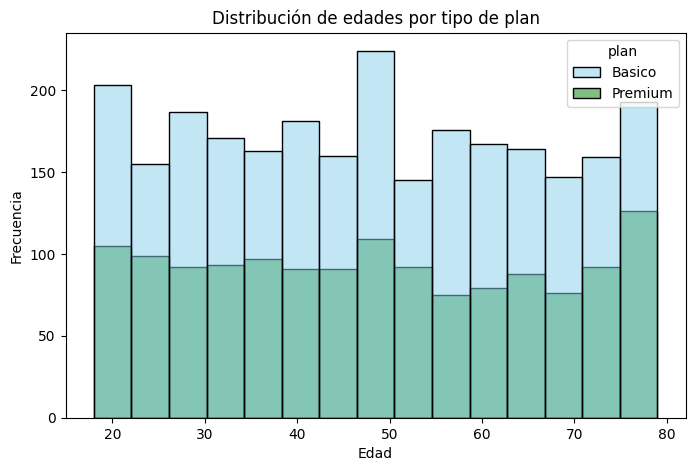

In [33]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de edades por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
La distribución de edades es relativamente uniforme entre los 18 y 79 años, sin concentraciones marcadas en un rango específico. El plan Básico presenta una mayor frecuencia de usuarios en todos los grupos de edad, lo cual es consistente con su mayor proporción dentro del dataset (64.88%). No se observa un patrón claro que indique que un tipo de plan sea preferido por un grupo de edad específico.

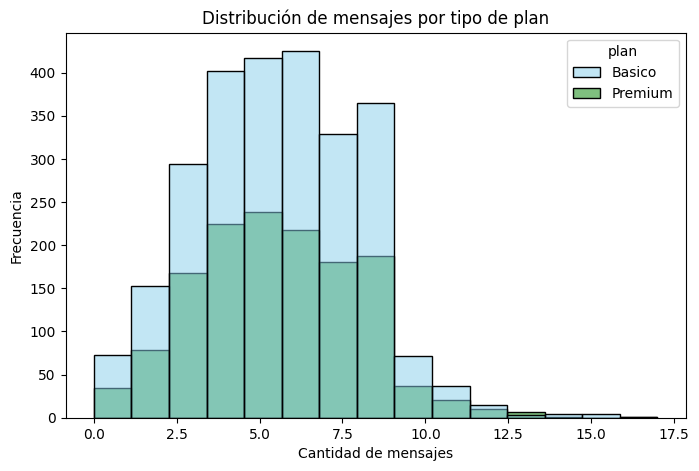

In [34]:

# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)


plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 

La mayoría de los usuarios envía entre 4 y 8 mensajes, independientemente del plan contratado. Aunque el plan básico presenta una mayor frecuencia de usuarios, esto es consistente con su mayor participación en el dataset. La distribución muestra un ligero sesgo hacia la derecha debido a algunos usuarios con un mayor volumen de mensajes.

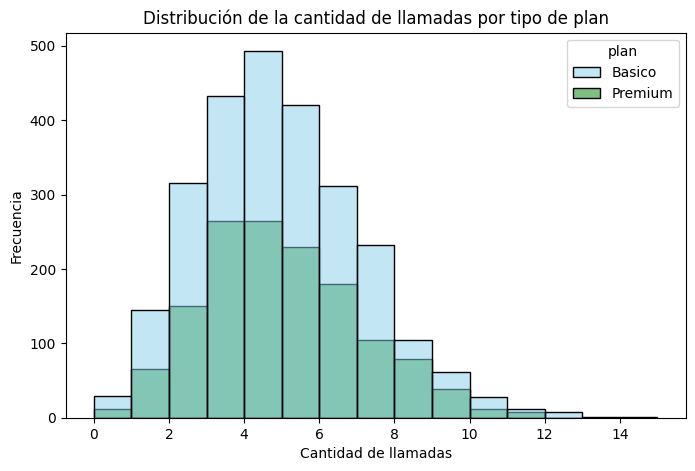

In [35]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de la cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 

La mayoría de los usuarios realiza entre 3 y 6 llamadas durante el período analizado. No se observan diferencias importantes entre los planes Básico y Premium en la distribución de llamadas. La presencia de algunos usuarios con un número elevado de llamadas genera una ligera asimetría positiva.

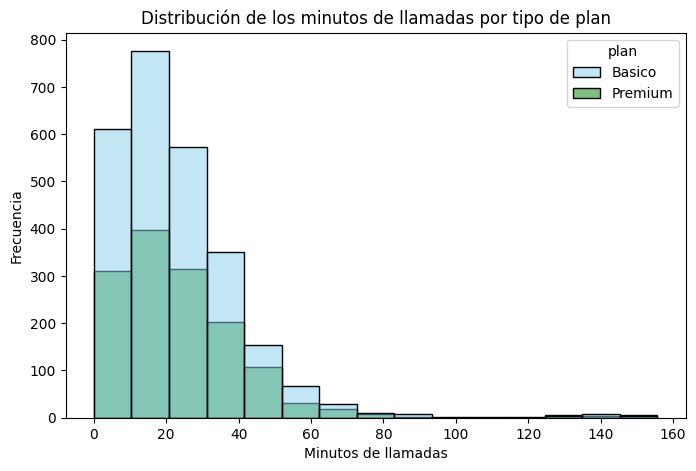

In [36]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de los minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 

La distribución de los minutos de llamadas presenta un claro sesgo hacia la derecha. La mayoría de los usuarios concentra un consumo bajo de minutos, mientras que un pequeño grupo registra consumos considerablemente mayores. Estos casos podrían representar valores atípicos y serán evaluados con mayor detalle en la etapa de detección de outliers.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

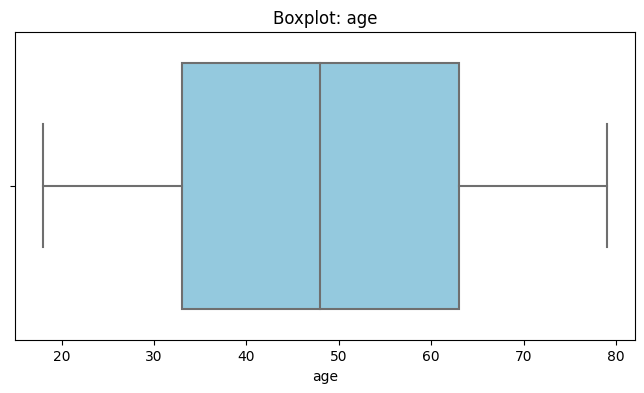

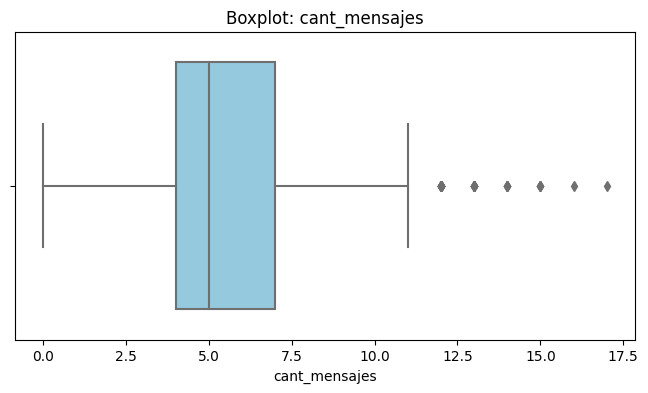

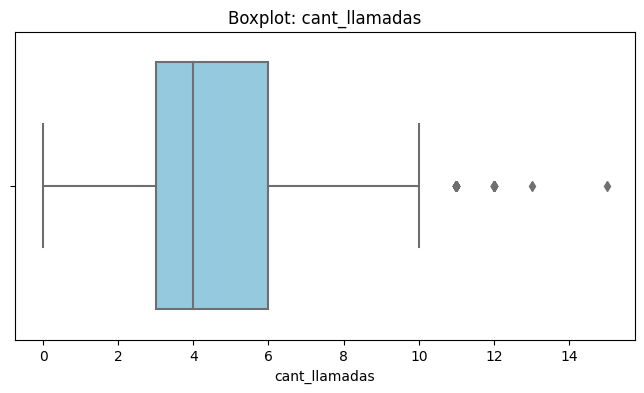

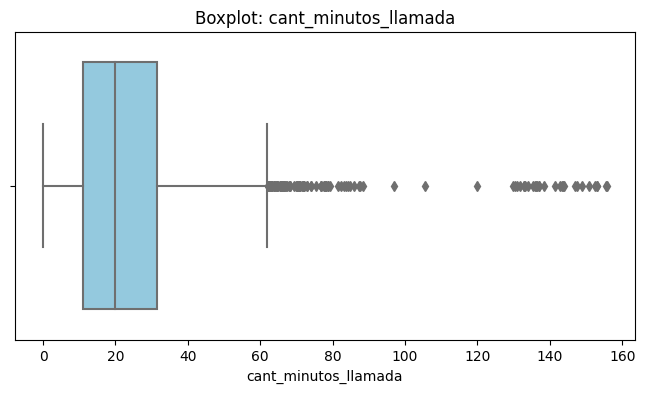

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue'
    )

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

💡Insights: 

- Age: no se observan valores atípicos. La distribución de edades se encuentra dentro de un rango esperado para la población analizada y no requiere tratamiento adicional.
  
- cant_mensajes: se identifican algunos valores atípicos en el extremo superior, correspondientes a usuarios con una cantidad de mensajes considerablemente mayor al resto. No se observan valores atípicos inferiores.

- cant_llamadas: se observan algunos valores atípicos en el extremo superior, correspondientes a usuarios con una mayor cantidad de llamadas. La mayoría de los usuarios mantiene un comportamiento similar.

- cant_minutos_llamada: la variable presenta una cantidad importante de valores atípicos en el extremo superior, indicando la existencia de usuarios con consumos de minutos significativamente mayores que la mayoría. Esto es consistente con la distribución sesgada hacia la derecha observada anteriormente.

In [38]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f'{col}')
    print(f'Q1: {q1:.2f}')
    print(f'Q3: {q3:.2f}')
    print(f'IQR: {iqr:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print('-' * 40)


cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior: 11.50
----------------------------------------
cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior: 10.50
----------------------------------------
cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite superior: 61.86
----------------------------------------


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().loc[['75%', 'max']]

,cant_mensajes,cant_llamadas,cant_minutos_llamada
75%,7.0,6.0,31.415
max,17.0,15.0,155.690


💡Insights: 

- cant_mensajes: mantener o no outliers, porqué?
Se identifican valores por encima del límite superior calculado mediante el método IQR. Sin embargo, representan usuarios con un mayor uso del servicio y no evidencian errores de captura, por lo que se conservarán para el análisis.

- cant_llamadas: mantener o no outliers, porqué?
Existen algunos valores atípicos en el extremo superior pero corresponden a usuarios con una frecuencia elevada de llamadas. Debido a que son coherentes con el contexto del negocio, se mantendrán.

- cant_minutos_llamada: mantener o no outliers, porqué?
Esta variable presenta la mayor cantidad de valores atípicos, con consumos considerablemente superiores al resto de usuarios. Al tratarse de un análisis del comportamiento de clientes y no de errores en los datos, estos registros se conservarán para representar adecuadamente a los usuarios de mayor consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso

def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'


user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad

def clasificar_edad(row):

    if row['age'] < 30:
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'


user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

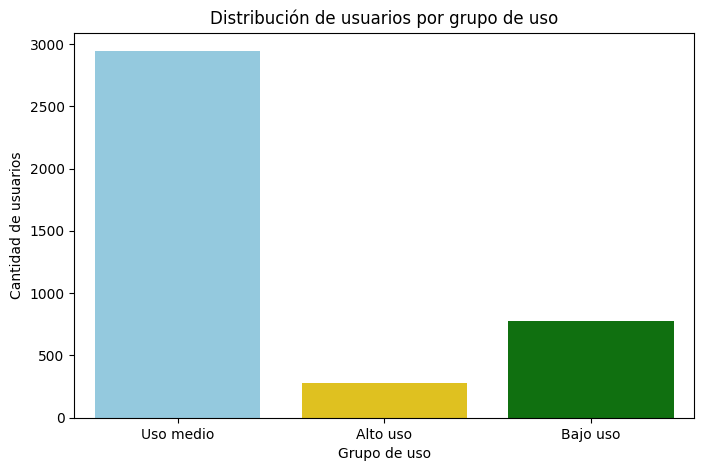

In [44]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

💡Insight: 
La mayor parte de los clientes se clasifica como usuarios de uso medio, lo que indica un comportamiento de consumo moderado en llamadas y mensajes. Los usuarios de alto uso son minoría, por lo que podrían representar un segmento específico para estrategias comerciales o planes especializados.

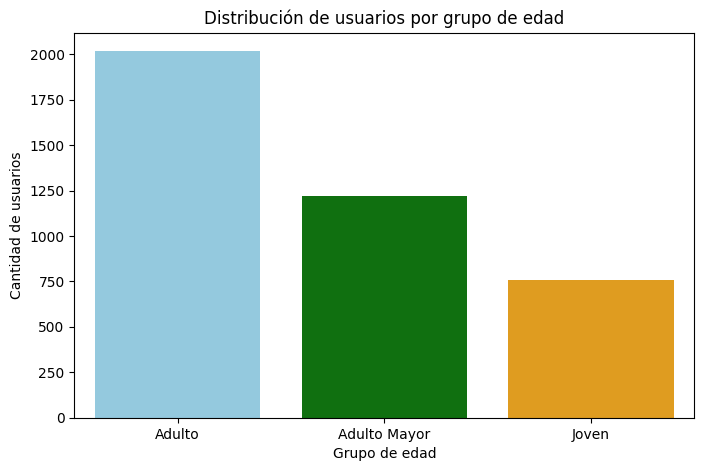

In [45]:
# Visualización de los segmentos por edad

plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

💡Insight: la población de clientes está compuesta principalmente por Adultos, seguidos por adultos mayores. Los usuarios jóvenes representan una menor proporción, lo que sugiere que la base de clientes de ConnectaTel está concentrada en edades medias y mayores.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificó un valor sentinel de -999 en la columna age, el cual fue reemplazado por la mediana para evitar sesgos en el análisis.
- La columna city presentó aproximadamente 11.7% de valores faltantes (incluyendo el sentinel "?"), los cuales se reemplazaron por valores nulos (NA).
- La columna "churn_date" presentó 88.35% de valores nulos; estos se conservaron ya que representan clientes que aún no han cancelado el servicio.
- Se detectaron **40 fechas de registro correspondientes al año 2026**, fuera del período del análisis (hasta 2024), por lo que fueron marcadas como valores nulos (NaT).
- En el dataset "usage", los valores nulos de **duration** y **length** dependen del tipo de registro (llamadas o mensajes), por lo que corresponden a valores esperados (MAR) y no requirieron ninguna imputación. 


🔍 **Segmentos por Edad**
- La mayor parte de los clientes pertenece al grupo de adultos (30-59 años).
- El segundo grupo más numeroso corresponde a **adultos mayores**, mientras que los **jóvenes** representan la menor proporción de clientes.
- Esto indica que la base de clientes de ConnectaTel se concentra principalmente en usuarios de edad media. 


📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes fue clasificada dentro del segmento de **uso medio**.
- El grupo de **bajo uso** representa una proporción menor de usuarios.
- El segmento de **alto uso** es el menos frecuente, aunque concentra clientes con un consumo considerablemente superior al promedio. 


➡️ Esto sugiere que la mayoría de los usuarios mantiene un consumo moderado de los servicios móviles, meintras que existe un grupo reducido de clientes con patrones de uso intensivo que podrían beneficiarse de ofertas o planes específicos. 

📈 **Patrones de uso extremo (Outliers)**
- Se identifican valores atípicos en las variables cant_mensajes, cant_llamadas y especialmente en cant_minutos_llamada.
- El método IQR confirmó la existencia de estos valores extremos; sin embargo, se decidió conservarlos porque representan comportamientos plausibles dentro del negocio y no errores de captura.
- Estos usuarios pueden corresponder a clientes de alto consumo y constituyen un segmento importante para el análisis comercial.

💡 **Recomendaciones**
- Diseñar planes o beneficios específicos para los usuarios de **alto uso**, ofreciendo mayores paquetes de minutos o mensajes para incentivar su permanencia.
- Implementar campañas dirigidas a los usuarios de **bajo uso** para incrementar el consumo mediante promociones o beneficios adicionales.
- Mejorar los procesos de captura y validación de datos para evitar registros con edades inválidas, ciudades incompletas y fechas futuras.
- Mantener el monitoreo de usuarios con consumos elevados para identificar oportunidades comerciales y así diferenciar comportamientos normales de posibles anomalías. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`